In [1]:
# from sklearn.model_selection import GridSearchCV
# from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_curve, auc
# from sklearn import svm
# from sklearn.ensemble import RandomForestClassifier
# from src.processing import Processing
import config
# from sklearn.feature_selection import SelectKBest, chi2
# import matplotlib.pyplot as plt
# import seaborn as sns
# import joblib
# import pandas as pd
# import numpy as np
# from imblearn.over_sampling import SMOTE
# from imblearn.under_sampling import RandomUnderSampler
import warnings
import random
# from src.datasplitting import DataSplitting
warnings.filterwarnings('ignore')
# from sklearn.model_selection import GridSearchCV, PredefinedSplit, TimeSeriesSplit
# # from sklearn.metrics import (
# #     accuracy_score, f1_score, precision_score, recall_score,
# #     confusion_matrix, roc_auc_score, precision_recall_curve, auc, classification_report
# )
# from src.processing import Processing
# from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score
# from sklearn.decomposition import PCA
# from sklearn.neighbors import KNeighborsClassifier
# from imblearn.under_sampling import EditedNearestNeighbours
# from imblearn.pipeline import make_pipeline, Pipeline
# from sklearn.preprocessing import StandardScaler
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
import os
# from imblearn.over_sampling import SMOTE
# from collections import Counter
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
import os
import gc
from tfrecordimagehandler import TFRecordImageHandler
# from tfrecordhandler import TFRecordDataHandler
# from src.datasplitting_for_images import DataSplittingForImages

In [9]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_data(image_batch, num_samples=5):
    plt.figure(figsize=(10, num_samples * 3))

    for i in range(num_samples):
        # Primer canal: la imagen en escala de grises
        plt.subplot(num_samples, 2, 2 * i + 1)
        plt.imshow(np.squeeze(image_batch[i, :, :, 0]), cmap='gray')  # Primer canal
        plt.title(f"Image")
        plt.axis('off')

        # Segundo canal: la máscara
        plt.subplot(num_samples, 2, 2 * i + 2)
        plt.imshow(np.squeeze(image_batch[i, :, :, 1]), cmap='gray')  # Segundo canal
        plt.title(f"Mask ")
        plt.axis('off')

    plt.show()

In [6]:
# Definir hiperparámetros
INPUT_DIR = 'input/deep_learning'
batch_size = 32
n_epochs = 10
checkpoint = './best_model_vgg.h5'
shuffle = True
verbose = 1

In [4]:
def _bytes_feature(value):
    """Returns a bytes_list from a string / byte."""
    return tf.train.Feature(bytes_list=tf.train.BytesList(value=[value]))

def _int64_feature(value):
    """Returns an int64_list from a bool / enum / int / uint."""
    return tf.train.Feature(int64_list=tf.train.Int64List(value=[value]))

def serialize_example(image_path, mask_path):
    img = tf.io.decode_image(tf.io.read_file(image_path), channels=3)
    img_bytes = img.numpy().tobytes()

    mask = tf.io.decode_image(tf.io.read_file(mask_path), channels=1)
    mask_bytes = mask.numpy().tobytes()

    # Get Study, Mice group and Day of study from the path
    path = os.path.normpath(mask_path)
    
    # Divide el path en partes
    path_parts = path.split(os.sep)

    # Extraer las partes relevantes
    # 0 for Cured Mice, 1 for Relapsing Mice, 2 for Control Mice
    if path_parts[2] == 'Cured mice':
        group_name = 1
    elif path_parts[2] == 'IMS-TMS-TREATED-RELAPSING':
        group_name = 0
    elif path_parts[2] == 'Control':
        group_name = 0
    else:
        print(path_parts)
        raise ValueError('Invalid group')
    mouse_id = path_parts[3]       # 'C1281'
    day_of_study = path_parts[4]   # 'day10'

    # Get only the integers in ids
    mouse_id = mouse_id[1:]
    day_of_study = day_of_study[3:]

    feature = {
        'image': _bytes_feature(img_bytes),
        'mask': _bytes_feature(mask_bytes),
        'height': _int64_feature(img.shape[0]),
        'width': _int64_feature(img.shape[1]),
        'mask_height': _int64_feature(mask.shape[0]),
        'mask_width': _int64_feature(mask.shape[1]),
        'group_name': _int64_feature(int(group_name)),
        'mouse_id': _int64_feature(int(mouse_id)),
        'day_of_study': _int64_feature(int(day_of_study))
    }
    
    return tf.train.Example(features=tf.train.Features(feature=feature)).SerializeToString()

def create_tfrecord(file_paths, output_file):
    with tf.io.TFRecordWriter(output_file) as writer:
        for img_path, mask_path in file_paths:
            if not os.path.exists(img_path) or not os.path.exists(mask_path):
                print(f'Image or mask not found: {img_path}, {mask_path}')
                continue
            writer.write(serialize_example(img_path, mask_path))

def split_dataset_by_m_id(root_dir, train_ratio=0.8):
    mouse_to_data = {}
    
    # Recorrer todas las imágenes y máscaras
    for data_group in os.listdir(root_dir):
        data_group_path = os.path.join(root_dir, data_group)
        if not os.path.isdir(data_group_path):
            continue
        for mice_group in os.listdir(data_group_path):
            mice_group_path = os.path.join(data_group_path, mice_group)
            if not os.path.isdir(mice_group_path):
                continue  # Saltar si no es un directorio
            for dayofstudy in os.listdir(mice_group_path):
                dayofstudy_path = os.path.join(mice_group_path, dayofstudy)
                if not os.path.isdir(dayofstudy_path):
                    continue  # Saltar si no es un directorio
                mri_imgs = os.path.join(dayofstudy_path, 'MRI images')
                if not os.path.exists(mri_imgs):
                    print(f"No se encontró la carpeta {mri_imgs}")
                    continue
                # Número de imágenes
                n_imgs = len(os.listdir(mri_imgs))
                for i in range(n_imgs):
                    img_path = os.path.join(mri_imgs, f'image_s{i + 1}.jpg')
                    mask_path = os.path.join(dayofstudy_path, f'Mask s{i + 1}.jpg')
                    
                    # Get Study, Mice group and Day of study from the path
                    path = os.path.normpath(mask_path)
                    
                    # Divide el path en partes
                    path_parts = path.split(os.sep)

                    # Extraer las partes relevantes
                    # 0 for Relapsing Mice, 1 for Cured Mice, 2 for Control Mice
                    if path_parts[2] == 'Cured mice':
                        group_name = 1
                    elif path_parts[2] == 'IMS-TMS-TREATED-RELAPSING':
                        group_name = 0
                    elif path_parts[2] == 'Control':
                        group_name = 0
                    else:
                        raise ValueError('Invalid group')
                    
                    mouse_id = path_parts[3]       # 'C1281'
                    day_of_study = path_parts[4]   # 'day10'

                    # Get only the integers in ids
                    mouse_id = mouse_id[1:]  # Remove 'C'
                    day_of_study = day_of_study[3:]  # Remove 'day'
                    
                    # Append data to mouse ID group
                    if mouse_id not in mouse_to_data:
                        mouse_to_data[mouse_id] = []
                    mouse_to_data[mouse_id].append((img_path, mask_path, group_name, mouse_id, day_of_study))

    print(mouse_to_data.head(2))

    # Split mouse IDs into train and test sets
    all_mice = list(mouse_to_data.keys())
    random.shuffle(all_mice)  # Shuffle IDs for randomness

    # Identify cured mice
    cured_mice = [mouse_id for mouse_id in all_mice if mouse_to_data[mouse_id][0][2] == 1]

    # Ensure at least one cured mouse in both train and test sets
    train_size = int(len(all_mice) * train_ratio)

    # Randomly shuffle cured mice to ensure diversity
    random.shuffle(cured_mice)

    # Ensure that at least one cured mouse is in the train and test sets
    train_mice = set(all_mice[:train_size])
    test_mice = set(all_mice[train_size:])

    # If the train set doesn't have a cured mouse, move one from test
    if not any(mouse_id in train_mice for mouse_id in cured_mice):
        train_mice.add(cured_mice[0])
        test_mice.remove(cured_mice[0])

    # If the test set doesn't have a cured mouse, move one from train
    if not any(mouse_id in test_mice for mouse_id in cured_mice):
        test_mice.add(cured_mice[0])
        train_mice.remove(cured_mice[0])

    # Check that both train and test sets have a cured mouse
    print(f'Train mice: {train_mice}')
    print(f'Test mice: {test_mice}')

    # Assign data to train and test sets
    train_data = [data for mouse_id in train_mice for data in mouse_to_data[mouse_id]]
    test_data = [data for mouse_id in test_mice for data in mouse_to_data[mouse_id]]

    train_paths = [(img, mask) for img, mask, *_ in train_data]
    test_paths = [(img, mask) for img, mask, *_ in test_data]

    print(f"Total data: {len(train_data) + len(test_data)}, Train: {len(train_data)}, Test: {len(test_data)}")
    
    return train_paths, test_paths


In [ ]:
train_data, test_data = split_dataset_by_m_id(config.DATASET_DIR, train_ratio=0.7)
train_tfrefcord = os.path.join(INPUT_DIR, 'train.tfrecord')
test_tfrefcord = os.path.join(INPUT_DIR, 'test.tfrecord')

create_tfrecord(train_data, train_tfrefcord)
create_tfrecord(test_data, test_tfrefcord)

In [7]:
train_tfrefcord = os.path.join(INPUT_DIR, 'train.tfrecord')
test_tfrefcord = os.path.join(INPUT_DIR, 'test.tfrecord')

Number of train samples: 242
Number of test samples: 140
Number of batches: 7
Images min: 0.0, max: 1.0


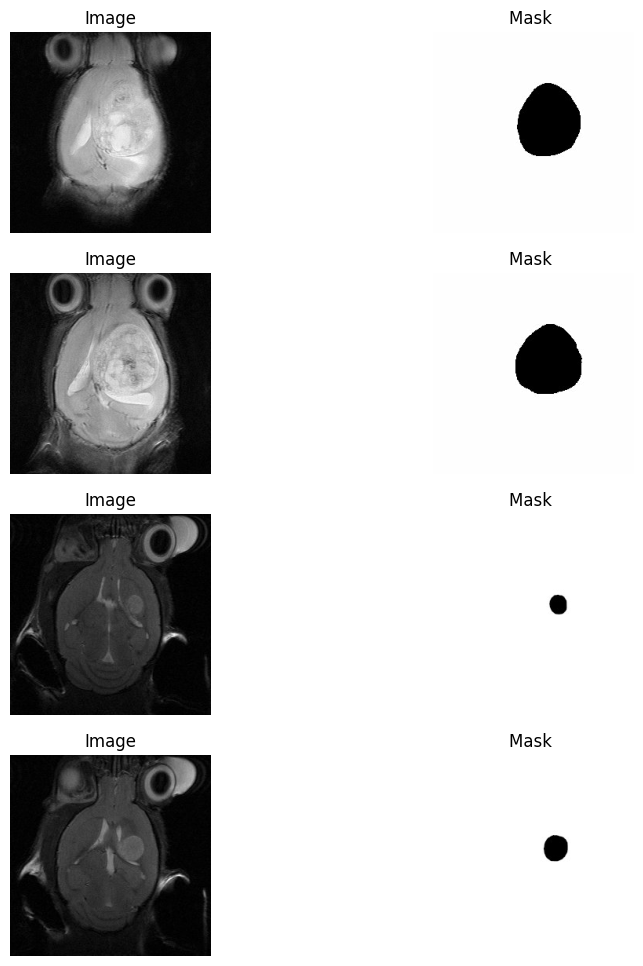

In [10]:
train_ds_handler = TFRecordImageHandler(train_tfrefcord, batch_size=batch_size, shuffle=False, augment=False)
train_ds = train_ds_handler.dataset
print(f"Number of train samples: {train_ds_handler.length}")

test_ds_handler = TFRecordImageHandler(test_tfrefcord, batch_size=batch_size, shuffle=False, augment=False)
test_ds = test_ds_handler.dataset
print(f"Number of test samples: {test_ds_handler.length}")

# Number of batches
n_batches = train_ds_handler.length // batch_size
print(f"Number of batches: {n_batches}")

images_tf, labels = next(iter(train_ds))

# Check if images are normalized
print(f"Images min: {images_tf.numpy().min()}, max: {images_tf.numpy().max()}")

visualize_data(images_tf, num_samples=4)
#visualize_data(images_tf, group_name_batches, num_samples=15)


In [ ]:
SEED = 42
tf.random.set_seed(SEED)

# Oversampling with data augmentation
def augment_data(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.2)
    return image, label

def count_instances(dataset):
    total_count = 0
    for images, labels in dataset:
        total_count += tf.size(labels)  # Count the number of labels (which equals the number of images in each batch)
    return total_count.numpy()  # Convert TensorFlow tensor to a regular integer

def oversample_minority_class(dataset, minority_class=1, factor=2):
    # Separate the minority and majority classes
    minority_ds = dataset.filter(lambda img, lbl: tf.reduce_any(lbl == minority_class))
    majority_ds = dataset.filter(lambda img, lbl: tf.reduce_any(lbl != minority_class))

    # Count instances before augmentation
    minority_count = count_instances(minority_ds)
    majority_count = count_instances(majority_ds)

    print(f"Before augmentation, Minority class size: {minority_count}, Majority class size: {majority_count}")
    
    # Augment the minority class data
    augmented_minority_ds = minority_ds.map(augment_data)
    for _ in range(factor - 1):
        augmented_minority_ds = augmented_minority_ds.concatenate(minority_ds.map(augment_data))

    # Recombine and shuffle
    balanced_ds = majority_ds.concatenate(augmented_minority_ds)
    
    # After oversampling, count again
    new_minority_count = count_instances(augmented_minority_ds)
    new_majority_count = count_instances(majority_ds)
    
    print(f"After augmentation, Minority class size: {new_minority_count}, Majority class size: {new_majority_count}")
    
    return balanced_ds.shuffle(buffer_size=1000, seed=SEED)

# Apply oversampling to the dataset
train_ds = oversample_minority_class(train_ds, minority_class=1, factor=3)

Before augmentation, Minority class size: 114, Majority class size: 242
After augmentation, Minority class size: 342, Majority class size: 242


In [7]:
# Print shape of images and masks
print(f"Images shape: {images_tf.shape}")

Images shape: (32, 256, 256, 3)


In [8]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.metrics import F1Score, AUC
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard
import cv2
import gc
import os
from datetime import datetime

# Define input_layer with the same shape that VGG16 expects
input_layer = tf.keras.layers.Input(shape=(256, 256, 3))

# Load the pre-trained VGG16 model
base_model = VGG16(weights='imagenet', include_top=False, input_tensor=input_layer)

# Freeze the base model layers
for layer in base_model.layers:
    layer.trainable = False

# Continue with custom layers
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)

# Define the model
model = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)

model.summary()

from sklearn.metrics import f1_score

def f1_macro(y_true, y_pred):
    # Convert the predicted probabilities to class labels (argmax operation along axis=1)
    y_pred = tf.argmax(y_pred, axis=1)
    
    # If y_true is sparse (integer labels), no need to apply tf.argmax, just use y_true as is
    y_true = tf.cast(y_true, tf.int64)
    
    # Convert tensors to numpy arrays before passing to f1_score
    y_true = y_true.numpy()
    y_pred = y_pred.numpy()
    
    # Compute F1 score
    return f1_score(y_true, y_pred, average='macro')

# Define directory paths for saving the model and TensorBoard logs
log_dir = os.path.join("logs", datetime.now().strftime("%Y%m%d-%H%M%S"))
model_save_path = "output/dl/{}/best_model.keras".format(datetime.now().strftime("%Y%m%d-%H%M%S"))

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_checkpoint = ModelCheckpoint(filepath=model_save_path, monitor='val_loss', save_best_only=True, verbose=1)
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1, write_graph=True, write_images=True)

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',  # Change based on your label encoding
    metrics=['accuracy', AUC()]
)

# Train the model
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=20,
    callbacks=[early_stopping, model_checkpoint, tensorboard_callback],
    verbose=1
)

# Print model save location and TensorBoard log directory
print(f"Best model saved to: {model_save_path}")
print(f"TensorBoard logs available at: {log_dir}")

# To visualize TensorBoard logs, use the following command in your terminal:
# tensorboard --logdir=logs

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 128, 128, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           25

 Total params: 14,847,297 (56.64 MB)

 Trainable params: 132,097 (516.00 KB)

 Non-trainable params: 14,715,200 (56.13 MB)

Epoch 1/20
     20/Unknown 19s 862ms/step - accuracy: 0.5977 - auc: 0.6556 - loss: 0.7040
Epoch 1: val_loss improved from inf to 0.31114, saving model to best_model.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.6021 - auc: 0.6615 - loss: 0.7001 - val_accuracy: 0.9429 - val_auc: 0.9295 - val_loss: 0.3111
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 857ms/step - accuracy: 0.7229 - auc: 0.8279 - loss: 0.5171
Epoch 2: val_loss improved from 0.31114 to 0.27346, saving model to best_model.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.7256 - auc: 0.8306 - loss: 0.5133 - val_accuracy: 0.9429 - val_auc: 0.9583 - val_loss: 0.2735
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 860ms/step - accuracy: 0.7567 - auc: 0.8920 - loss: 0.4538
Epoch 3: val_loss did not improve from 0.27346
20/20 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.7579 - auc: 0.8917 - loss: 0.4525 - val_accuracy: 0.9429 - val_auc: 0.9569 - val_loss: 0.2767
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 864ms/step - ac

In [2]:
model_save_path = "output/dl/best_model.keras"

model = tf.keras.models.load_model(model_save_path)

In [11]:
for layer in model.layers:
    print(layer.name)

input_layer_1
block1_conv1
block1_conv2
block1_pool
block2_conv1
block2_conv2
block2_pool
block3_conv1
block3_conv2
block3_conv3
block3_pool
block4_conv1
block4_conv2
block4_conv3
block4_pool
block5_conv1
block5_conv2
block5_conv3
block5_pool
global_average_pooling2d_1
dense_2
dropout_1
dense_3


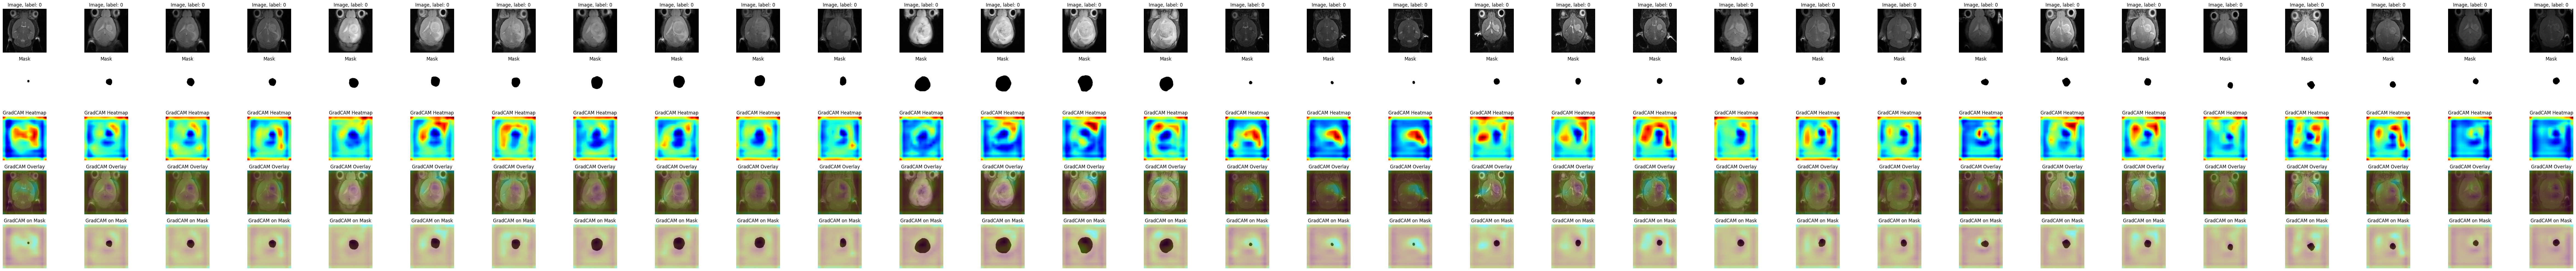

KeyboardInterrupt: 

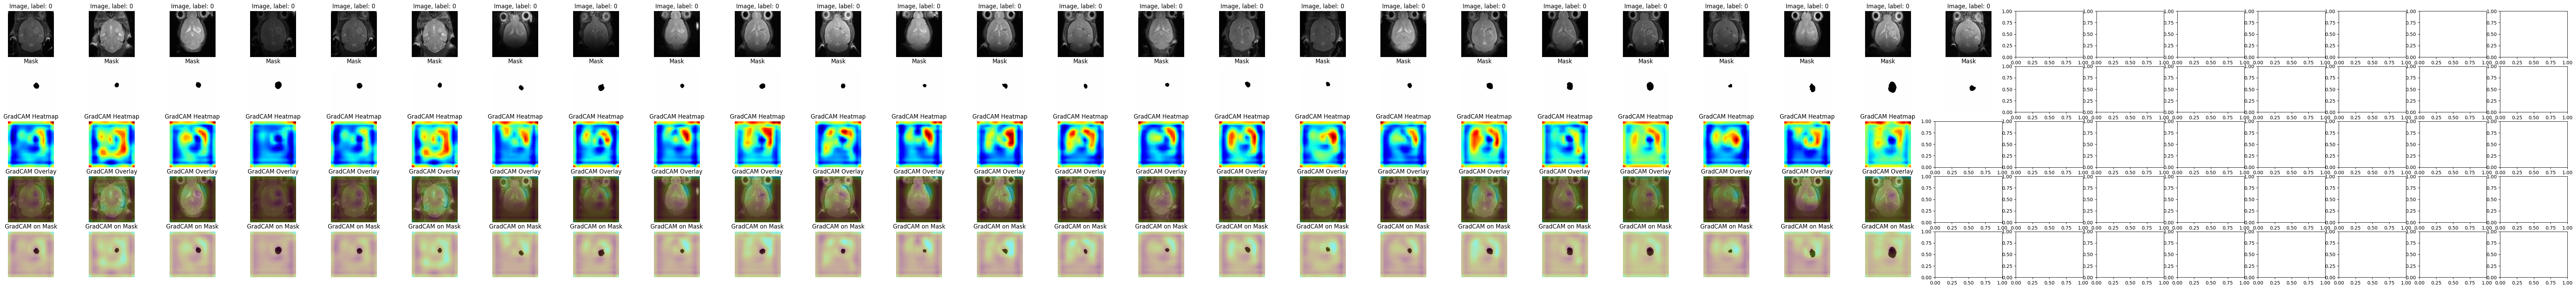

In [11]:
from src.notebooks.dl.gradcam import GradCAM
import matplotlib.pyplot as plt
import numpy as np
import cv2

for image_batch, labels_batch in test_ds:
    batch_size = image_batch.shape[0]
    fig, axes = plt.subplots(5, batch_size, figsize=(3 * batch_size, 10))

    for i, (image, label) in enumerate(zip(image_batch, labels_batch)):
        image = image.numpy()  # Convertir tensor a NumPy array
        label = int(label.numpy())  # Asegurar que la etiqueta sea un entero

        # Imagen en escala de grises
        axes[0, i].imshow(np.squeeze(image[:, :, 0]), cmap='gray')
        axes[0, i].set_title(f"Image, label: {label}")
        axes[0, i].axis('off')

        # Máscara
        axes[1, i].imshow(np.squeeze(image[:, :, 1]), cmap='gray')
        axes[1, i].set_title("Mask")
        axes[1, i].axis('off')

        # GradCAM Heatmap
        gradcam = GradCAM(model, classIdx=label, layerName='block5_conv3')
        heatmap = gradcam.compute_heatmap(np.expand_dims(image, axis=0))
        axes[2, i].imshow(heatmap, cmap='jet')
        axes[2, i].set_title("GradCAM Heatmap")
        axes[2, i].axis('off')

        # GradCAM Overlay en imagen original
        grayscale_image = (image[:, :, 0] * 255).astype(np.uint8)  # Convertir a escala de grises uint8
        grayscale_image = cv2.cvtColor(grayscale_image, cv2.COLOR_GRAY2RGB)  # Convertir a RGB
        overlay = gradcam.overlay_heatmap(heatmap, grayscale_image)[1]
        axes[3, i].imshow(overlay)
        axes[3, i].set_title("GradCAM Overlay")
        axes[3, i].axis('off')

        # GradCAM Overlay en máscara
        mask_image = (image[:, :, 1] * 255).astype(np.uint8)  # Convertir máscara a uint8
        mask_image = cv2.cvtColor(mask_image, cv2.COLOR_GRAY2RGB)  # Convertir a RGB
        overlay_mask = gradcam.overlay_heatmap(heatmap, mask_image)[1]
        axes[4, i].imshow(overlay_mask)
        axes[4, i].set_title("GradCAM on Mask")
        axes[4, i].axis('off')
    
    plt.tight_layout()
    plt.show()



In [16]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras import backend as K

# Function to get Grad-CAM heatmap
def get_gradcam_heatmap(model, img_array, class_index, layer_name="block5_conv3"):
    # Get the gradient of the class with respect to the last convolutional layer
    with tf.GradientTape() as tape:
        # The input image is the batch with shape (1, 256, 256, 3)
        last_conv_layer = model.get_layer(layer_name)
        tape.watch(last_conv_layer.output)
        preds = model(img_array)
        class_output = preds[:, class_index]
    
    # Get gradients of the predicted class with respect to the last conv layer
    grads = tape.gradient(class_output, last_conv_layer.output)
    
    # Pool the gradients across all the axes (height, width)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    # Multiply each channel in the feature map by the mean gradient
    last_conv_layer_output = last_conv_layer.output[0]
    for i in range(last_conv_layer_output.shape[-1]):
        last_conv_layer_output[:, :, i] *= pooled_grads[i]
    
    # Create the heatmap by averaging over all channels
    heatmap = tf.reduce_mean(last_conv_layer_output, axis=-1)
    
    # Normalize the heatmap
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap)
    
    return heatmap

# Function to display Grad-CAM results
def display_gradcam(img, heatmap, alpha=0.4):
    # Resize heatmap to match the image dimensions
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    
    # Convert heatmap to RGB
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    
    # Overlay heatmap on the image
    superimposed_img = cv2.addWeighted(img, 1 - alpha, heatmap, alpha, 0)
    
    return superimposed_img

# Function to generate Grad-CAM for a sample from the test set
def gradcam_visualization(model, test_ds, n_images=3):
    # Pick some images from the test dataset
    test_images, test_labels = next(iter(test_ds))
    
    # Get class indices (assumes binary classification here)
    class_indices = np.argmax(test_labels, axis=1)
    
    # Plot results for the first few images
    for i in range(n_images):
        img = test_images[i].numpy().astype("uint8")  # Convert to numpy for display
        true_label = class_indices[i]
        
        # Get Grad-CAM heatmap
        heatmap = get_gradcam_heatmap(model, test_images[i:i+1], true_label)
        
        # Overlay Grad-CAM heatmap on the image
        superimposed_img = display_gradcam(img, heatmap)
        
        # Plot original image and Grad-CAM heatmap
        plt.figure(figsize=(12, 6))
        
        # Original Image
        plt.subplot(1, 2, 1)
        plt.imshow(img)
        plt.title(f"Original Image (True: {true_label})")
        plt.axis('off')
        
        # Image with Grad-CAM overlay
        plt.subplot(1, 2, 2)
        plt.imshow(superimposed_img)
        plt.title(f"Grad-CAM Overlay (True: {true_label})")
        plt.axis('off')
        
        plt.show()


